# Chapter 10 — Naive Bayes

**Goals**

- Implement Gaussian Naive Bayes from scratch in NumPy.
- Apply Multinomial Naive Bayes (with Laplace smoothing) to a bag-of-words text task.
- Compare against scikit-learn.

Pair with `docs/04_classification.md`, Part B.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)

## 2. Gaussian Naive Bayes from scratch

For each class $c$ we estimate the per-feature mean $\mu_{jc}$ and variance $\sigma^2_{jc}$ on the training data. Prediction is
$$\hat{y} = \arg\max_c \Big[\log P(y = c) + \sum_j \log \mathcal{N}(x_j \mid \mu_{jc}, \sigma^2_{jc})\Big].$$

In [2]:
class GaussianNBScratch:
    def __init__(self, var_smoothing: float = 1e-9):
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors_  = np.array([(y == c).mean() for c in self.classes_])
        self.means_   = np.array([X[y == c].mean(axis=0) for c in self.classes_])
        self.vars_    = np.array([X[y == c].var(axis=0)  for c in self.classes_]) + self.var_smoothing
        return self

    def _log_likelihood(self, X):
        # log N(x | mu, sigma^2) = -0.5 * log(2*pi*sigma^2) - 0.5 * (x - mu)^2 / sigma^2
        log_lik = np.zeros((X.shape[0], len(self.classes_)))
        for k, _ in enumerate(self.classes_):
            mu, var = self.means_[k], self.vars_[k]
            log_lik[:, k] = (-0.5 * np.sum(np.log(2 * np.pi * var))
                             - 0.5 * np.sum(((X - mu) ** 2) / var, axis=1))
        return log_lik

    def predict(self, X):
        log_posterior = self._log_likelihood(X) + np.log(self.priors_)
        return self.classes_[np.argmax(log_posterior, axis=1)]

## 3. Sanity-check on Iris

In [3]:
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, stratify=iris.target, random_state=SEED
)

scratch = GaussianNBScratch().fit(X_train, y_train)
sklearn = GaussianNB().fit(X_train, y_train)

print(f'scratch  accuracy = {accuracy_score(y_test, scratch.predict(X_test)):.4f}')
print(f'sklearn  accuracy = {accuracy_score(y_test, sklearn.predict(X_test)):.4f}')
assert np.array_equal(scratch.predict(X_test), sklearn.predict(X_test))

scratch  accuracy = 0.9667
sklearn  accuracy = 0.9667


## 4. Multinomial Naive Bayes for text

We pull a subset of *20 newsgroups* (4 categories), bag-of-words encode it, and train Multinomial NB.

In [4]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'), random_state=SEED)
test  = fetch_20newsgroups(subset='test',  categories=categories, remove=('headers', 'footers', 'quotes'), random_state=SEED)

vectorizer = CountVectorizer(min_df=5, stop_words='english')
X_train_tf = vectorizer.fit_transform(train.data)
X_test_tf  = vectorizer.transform(test.data)
print(f'vocabulary size: {len(vectorizer.get_feature_names_out())}')
print(f'train docs: {X_train_tf.shape[0]}, test docs: {X_test_tf.shape[0]}')

vocabulary size: 5620
train docs: 2257, test docs: 1502


In [5]:
mnb = MultinomialNB(alpha=1.0).fit(X_train_tf, train.target)
y_pred = mnb.predict(X_test_tf)
print(f'MultinomialNB test accuracy = {accuracy_score(test.target, y_pred):.4f}')
print()
print(classification_report(test.target, y_pred, target_names=categories))

MultinomialNB test accuracy = 0.8182

                        precision    recall  f1-score   support

           alt.atheism       0.74      0.66      0.70       319
soc.religion.christian       0.93      0.89      0.91       389
         comp.graphics       0.89      0.84      0.86       396
               sci.med       0.72      0.85      0.78       398

              accuracy                           0.82      1502
             macro avg       0.82      0.81      0.81      1502
          weighted avg       0.82      0.82      0.82      1502



## 5. Inspecting what the model learned

Each row of `feature_log_prob_` is the log $P(\text{word} \mid \text{class})$. Sort within a class to see which words it associates most strongly with that class.

In [6]:
vocab = np.array(vectorizer.get_feature_names_out())
top_n = 10
for ci, name in enumerate(categories):
    top_words = vocab[np.argsort(mnb.feature_log_prob_[ci])[-top_n:][::-1]]
    print(f'{name:30s}  top {top_n}: {", ".join(top_words)}')

alt.atheism                     top 10: god, people, don, think, just, does, atheism, say, believe, atheists
soc.religion.christian          top 10: image, graphics, edu, jpeg, file, use, data, files, images, software
comp.graphics                   top 10: edu, don, people, health, use, medical, like, know, com, time
sci.med                         top 10: god, jesus, people, church, think, does, know, believe, don, christ


## 6. Confusion matrix

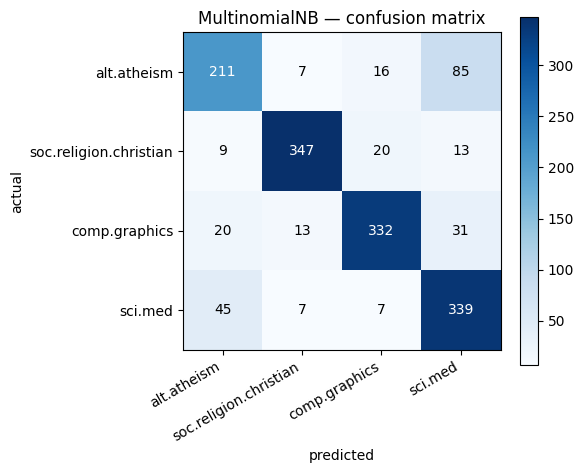

In [7]:
cm = confusion_matrix(test.target, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(categories))); ax.set_yticks(range(len(categories)))
ax.set_xticklabels(categories, rotation=30, ha='right'); ax.set_yticklabels(categories)
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('MultinomialNB — confusion matrix')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black' if cm[i, j] < cm.max() * 0.5 else 'white')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 7. Effect of Laplace smoothing

In [8]:
alphas = [0.0001, 0.01, 1.0, 10.0]
for a in alphas:
    acc = accuracy_score(test.target, MultinomialNB(alpha=a).fit(X_train_tf, train.target).predict(X_test_tf))
    print(f'alpha = {a:>8.4f}  accuracy = {acc:.4f}')

alpha =   0.0001  accuracy = 0.8009
alpha =   0.0100  accuracy = 0.8089
alpha =   1.0000  accuracy = 0.8182
alpha =  10.0000  accuracy = 0.7816


Too small alpha → unseen words have near-zero probability and dominate. Too large → smoothing washes out signal. A modest alpha (0.01-1.0) is the safe range.

## 8. Summary

- Gaussian NB: per-class Gaussian fit, closed-form. Decent on small numeric problems.
- Multinomial NB: count-based, trains in seconds on tens of thousands of features.
- Laplace smoothing prevents zero-probability collapse and is essentially free.
- For text, MNB is a great baseline before you reach for transformers.

**Next:** Logistic Regression in `notebooks/chapter_10_logistic_regression.ipynb`.